## LDA

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA

OUTPUT_DIR = 'tables'

In [3]:
OHCO = ['film_name', 'chunk_num', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:3],
    CHUNKS = OHCO[:2],
    FILMS = OHCO[:1]
)

LIB = pd.read_csv('tables/LIB.csv').set_index('film_name')
CORPUS = pd.read_csv('tables/CORPUS.csv').set_index(OHCO)

# Filter corpus to only include nouns
DOCS = CORPUS[CORPUS.pos.str.match(r'^NNS?$')]\
    .groupby(bags['CHUNKS']).term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'}).join(LIB[['director']])
DOCS

doc_str  director
film_name         chunk_num                               
castle_in_the_sky 0                           ah  Miyazaki
                  1          wah gas bomb attack  Miyazaki
                  2                          wah  Miyazaki
                  3                   ah wah hey  Miyazaki
                  4                        floor  Miyazaki
...                                          ...       ...
the_wind_rises    966                    someone  Miyazaki
                  967                     nahoko  Miyazaki
                  968                       time  Miyazaki
                  972                       wind  Miyazaki
                  975                 house wine  Miyazaki

[8608 rows x 2 columns]

## Create Vector Space

In [4]:
from sklearn.feature_extraction import text

count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words='english')
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

age  ah  ahh  ahhh  air  airplanes  anger  army  \
film_name         chunk_num                                                    
castle_in_the_sky 0            0   1    0     0    0          0      0     0   
                  1            0   0    0     0    0          0      0     0   
                  2            0   0    0     0    0          0      0     0   
                  3            0   1    0     0    0          0      0     0   
                  4            0   0    0     0    0          0      0     0   
...                          ...  ..  ...   ...  ...        ...    ...   ...   
the_wind_rises    966          0   0    0     0    0          0      0     0   
                  967          0   0    0     0    0          0      0     0   
                  968          0   0    0     0    0          0      0     0   
                  972          0   0    0     0    0          0      0     0   
                  975          0   0    0     0    0          0      0     0   

                             attack  attention  ...  words  work  world  \
film_name         chunk_num                     ...                       
castle_in_the_sky 0               0          0  ...      0     0      0   
                  1               1          0  ...      0     0      0   
                  2               0          0  ...      0     0      0   
                  3               0          0  ...      0     0      0   
                  4               0          0  ...      0     0      0   
...                             ...        ...  ...    ...   ...    ...   
the_wind_rises    966             0          0  ...      0     0      0   
                  967             0          0  ...      0     0      0   
                  968             0          0  ...      0     0      0   
                  972             0          0  ...      0     0      0   
                  975             0          0  ...      0     0      0   

                             worry  wound  wow  yeah  year  years  yep  
film_name         chunk_num                                             
castle_in_the_sky 0              0      0    0     0     0      0    0  
                  1              0      0    0     0     0      0    0  
                  2              0      0    0     0     0      0    0  
                  3              0      0    0     0     0      0    0  
                  4              0      0    0     0     0      0    0  
...                            ...    ...  ...   ...   ...    ...  ...  
the_wind_rises    966            0      0    0     0     0      0    0  
                  967            0      0    0     0     0      0    0  
                  968            0      0    0     0     0      0    0  
                  972            0      0    0     0     0      0    0  
                  975            0      0    0     0     0      0    0  

[8608 rows x 307 columns]

## Generate Model

In [5]:
n_topics = 20
max_iter = 100
n_top_terms = 5
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

In [6]:
topic_engine = LDA(n_components=n_topics, max_iter=max_iter, random_state=42)
topic_model = topic_engine.fit_transform(count_model)

In [7]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(cmap="YlGnBu", axis=None)

In [8]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.T.sample(10).T.style.background_gradient(cmap="YlGnBu", axis=None)

term_str,ohh,pilots,living,car,valley,emergency,run,hat,door,police
topic_id,,,,,,,,,,
T00,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T01,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T02,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T03,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T04,0.050000,0.050000,0.050000,0.050000,4.243783,0.050000,0.050000,0.050000,0.050000,0.050000
T05,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T06,28.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,11.050000,0.050000,0.050000
T07,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,23.050000,0.050000
T08,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000


## Create Topics

In [9]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS

,top_terms
topic_id,
T00,humans school job transformation luck
T01,girl work father trouble plane
T02,thing man things care oh
T03,look today mountain power use
T04,wind everybody sea morning problem
T05,time water war days round
T06,matter house boy face ohh
T07,forest course lady spell door
T08,help years pig head hand


In [10]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

,top_terms,doc_weight_sum,term_freq
topic_id,,,
T05,time water war days round,479.249899,0.065220
T16,way princess wait idea spirit,477.368293,0.062465
T15,thanks trees mom gold flowers,458.212165,0.059114
T17,ah ship mother witch hospital,453.442900,0.053947
T01,girl work father trouble plane,451.743117,0.057667
T02,thing man things care oh,451.253800,0.056433
T12,raccoons place hurry boat minute,442.549670,0.053192
T18,heart raccoon town stone hands,442.468189,0.052604
T11,world wah night child hey,437.617729,0.052049


## Sort Topics by Doc Weight

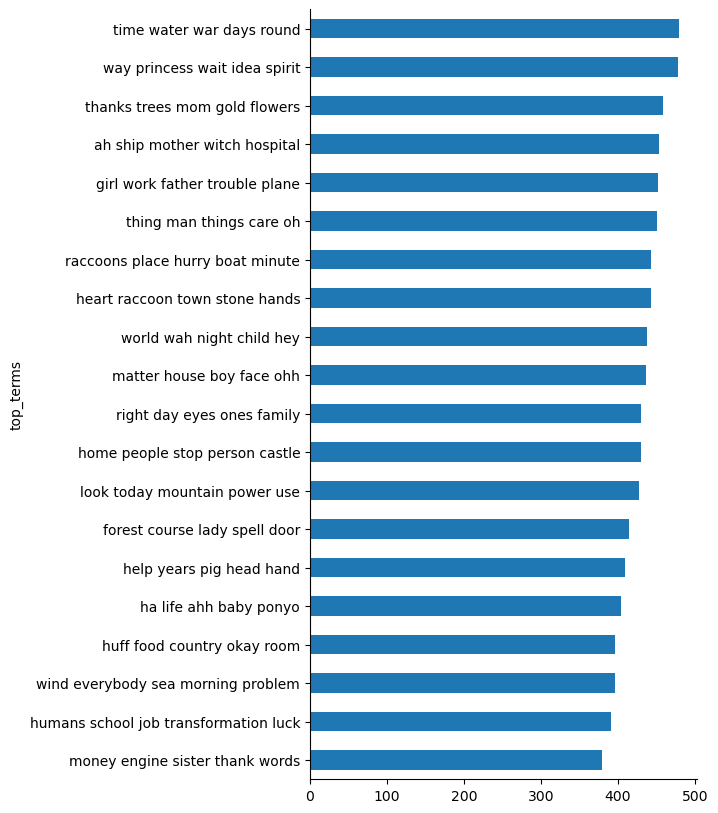

In [11]:
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='top_terms', figsize=(5, n_topics/2), legend=False)
sns.despine()
plt.show()

In [12]:
THETAX = THETA.join(LIB).reset_index().set_index(['film_name', 'director', 'chunk_num']).iloc[:, :-3]
THETAX

T00     T01     T02     T03     T04  \
film_name         director chunk_num                                           
castle_in_the_sky Miyazaki 0          0.0250  0.0250  0.0250  0.0250  0.0250   
                           1          0.2625  0.0125  0.0125  0.0125  0.0125   
                           2          0.0250  0.0250  0.0250  0.0250  0.0250   
                           3          0.0125  0.0125  0.0125  0.0125  0.0125   
                           4          0.0500  0.0500  0.0500  0.0500  0.0500   
...                                      ...     ...     ...     ...     ...   
the_wind_rises    Miyazaki 966        0.0500  0.0500  0.0500  0.0500  0.0500   
                           967        0.0500  0.0500  0.0500  0.0500  0.0500   
                           968        0.0250  0.0250  0.0250  0.0250  0.0250   
                           972        0.0250  0.0250  0.0250  0.0250  0.5250   
                           975        0.0250  0.0250  0.0250  0.0250  0.0250   

                                         T05     T06     T07     T08     T09  \
film_name         director chunk_num                                           
castle_in_the_sky Miyazaki 0          0.0250  0.0250  0.0250  0.0250  0.0250   
                           1          0.0125  0.0125  0.0125  0.0125  0.0125   
                           2          0.0250  0.0250  0.0250  0.0250  0.0250   
                           3          0.0125  0.0125  0.0125  0.0125  0.0125   
                           4          0.0500  0.0500  0.0500  0.0500  0.0500   
...                                      ...     ...     ...     ...     ...   
the_wind_rises    Miyazaki 966        0.0500  0.0500  0.0500  0.0500  0.0500   
                           967        0.0500  0.0500  0.0500  0.0500  0.0500   
                           968        0.5250  0.0250  0.0250  0.0250  0.0250   
                           972        0.0250  0.0250  0.0250  0.0250  0.0250   
                           975        0.0250  0.5250  0.0250  0.0250  0.0250   

                                         T10     T11     T12     T13     T14  \
film_name         director chunk_num                                           
castle_in_the_sky Miyazaki 0          0.0250  0.0250  0.0250  0.0250  0.0250   
                           1          0.0125  0.2625  0.0125  0.0125  0.0125   
                           2          0.0250  0.5250  0.0250  0.0250  0.0250   
                           3          0.0125  0.5125  0.0125  0.0125  0.0125   
                           4          0.0500  0.0500  0.0500  0.0500  0.0500   
...                                      ...     ...     ...     ...     ...   
the_wind_rises    Miyazaki 966        0.0500  0.0500  0.0500  0.0500  0.0500   
                           967        0.0500  0.0500  0.0500  0.0500  0.0500   
                           968        0.0250  0.0250  0.0250  0.0250  0.0250   
                           972        0.0250  0.0250  0.0250  0.0250  0.0250   
                           975        0.0250  0.0250  0.0250  0.0250  0.0250   

                                         T15     T16     T17     T18     T19  
film_name         director chunk_num                                          
castle_in_the_sky Miyazaki 0          0.0250  0.0250  0.5250  0.0250  0.0250  
                           1          0.0125  0.0125  0.0125  0.0125  0.2625  
                           2          0.0250  0.0250  0.0250  0.0250  0.0250  
                           3          0.0125  0.0125  0.2625  0.0125  0.0125  
                           4          0.0500  0.0500  0.0500  0.0500  0.0500  
...                                      ...     ...     ...     ...     ...  
the_wind_rises    Miyazaki 966        0.0500  0.0500  0.0500  0.0500  0.0500  
                           967        0.0500  0.0500  0.0500  0.0500  0.0500  
                           968        0.0250  0.0250  0.0250  0.0250  0.0250  
                           972        0.0250  0.0

In [13]:
TOPIC_FILM = THETAX.groupby('film_name').mean()
TOPIC_FILM.T.style.background_gradient(axis=0, cmap="YlGnBu")

film_name,castle_in_the_sky,grave_of_the_fireflies,howls_moving_castle,kikis_delivery_service,my_neighbor_totoro,nausicaa,only_yesterday,pom_poko,ponyo,porco_rosso,princess_kaguya,princess_mononoke,spirited_away,the_wind_rises
T00,0.032343,0.048406,0.033063,0.033080,0.033086,0.034183,0.058219,0.074142,0.043015,0.037878,0.033678,0.052115,0.053307,0.040151
T01,0.068612,0.045784,0.042797,0.061302,0.054178,0.042843,0.058379,0.041189,0.047856,0.070928,0.047624,0.047301,0.058806,0.068148
T02,0.058377,0.053082,0.060560,0.053003,0.047914,0.047011,0.058185,0.046360,0.058921,0.040726,0.046422,0.062977,0.052052,0.050404
T03,0.050520,0.053736,0.044062,0.043197,0.059925,0.045629,0.040405,0.049031,0.055636,0.041413,0.052544,0.064122,0.048875,0.056187
T04,0.044204,0.044848,0.036808,0.057701,0.049523,0.048278,0.039782,0.041254,0.061687,0.048994,0.052726,0.037814,0.045323,0.050141
T05,0.046772,0.071246,0.055752,0.060661,0.050902,0.054577,0.057980,0.047146,0.048548,0.063806,0.073134,0.050706,0.056443,0.054583
T06,0.056336,0.061078,0.058839,0.055065,0.060730,0.058726,0.045932,0.042825,0.047165,0.058614,0.040141,0.041841,0.040813,0.059604
T07,0.040189,0.037794,0.055938,0.056711,0.045845,0.036827,0.048386,0.052291,0.045090,0.044982,0.052454,0.052051,0.046490,0.043884
T08,0.046213,0.039570,0.042898,0.040044,0.044293,0.038864,0.062438,0.044619,0.041459,0.070762,0.044222,0.053648,0.043005,0.057238
T09,0.045893,0.049497,0.054268,0.054147,0.057626,0.041515,0.054282,0.048573,0.051660,0.033422,0.057873,0.042640,0.055225,0.051192


In [14]:
TOPIC_DIRECTOR = THETAX.groupby('director').mean().T.join(TOPICS[['top_terms', 'doc_weight_sum', 'term_freq']])
TOPIC_DIRECTOR.style.background_gradient(axis=0, cmap="YlGnBu")

,Miyazaki,Takahata,top_terms,doc_weight_sum,term_freq
T00,0.039223,0.058081,humans school job transformation luck,390.395101,0.038017
T01,0.055344,0.046531,girl work father trouble plane,451.743117,0.057667
T02,0.053961,0.049228,thing man things care oh,451.253800,0.056433
T03,0.050164,0.048790,look today mountain power use,427.966598,0.052021
T04,0.046780,0.044335,wind everybody sea morning problem,395.844295,0.039246
T05,0.054412,0.058297,time water war days round,479.249899,0.065220
T06,0.053794,0.044443,matter house boy face ohh,436.893242,0.051618
T07,0.047223,0.050220,forest course lady spell door,414.885180,0.046094
T08,0.047512,0.047364,help years pig head hand,408.567118,0.042381
T09,0.048818,0.052171,right day eyes ones family,429.607475,0.049108


## Visualizations

In [15]:
from sklearn.decomposition import PCA

# Apply PCA to the THETA table
pca_engine = PCA(n_components=5)
TCM = pd.DataFrame(pca_engine.fit_transform(THETA.T), index = THETA.T.index)
TCM.columns = ['PC{}'.format(i) for i in TCM.columns]
TCM['mean_weight'] = THETA.mean(axis=0)
TCM

,PC0,PC1,PC2,PC3,PC4,mean_weight
topic_id,,,,,,
T00,-0.418660,-0.265669,-0.498750,-0.355722,-0.100872,0.045353
T01,0.008130,-0.933590,-0.219527,-0.739106,6.172759,0.052479
T02,0.473475,-0.805198,-0.089215,-2.699239,-5.508674,0.052423
T03,0.247006,-0.442852,-0.019166,-0.358326,-1.007984,0.049717
T04,-0.216635,-0.483178,-0.066515,-0.154927,0.193583,0.045986
T05,-5.952670,6.998396,-0.223370,0.502657,-0.035177,0.055675
T06,-0.198842,-0.830339,-0.157899,-0.575501,1.214997,0.050754
T07,-0.215381,-0.741721,0.324972,-0.392658,0.661340,0.048198
T08,-0.378100,-0.618393,-0.126397,-0.506617,0.437311,0.047464


In [16]:
TCM['director'] = TOPIC_DIRECTOR[['Miyazaki', 'Takahata']].idxmax(axis=1)
TCM['top_terms'] = TOPICS['top_terms']

px.scatter(
    TCM.reset_index(),
    x='PC0', y='PC1',
    size='mean_weight',
    color='director',
    text='topic_id',
    hover_data={'top_terms': True, 'mean_weight': ':.4f', 'PC0': False, 'PC1': False},
    height=600,
    width=800
)

## Save Tables

In [17]:
TOPICS.to_csv(f'{OUTPUT_DIR}/TOPICS.csv')
THETA.to_csv(f'{OUTPUT_DIR}/THETA.csv')
PHI.to_csv(f'{OUTPUT_DIR}/PHI.csv')